# 07 — FGSM Attack (Adversarial Robustness Toolbox)

**Purpose.** Evaluate adversarial robustness of the 8 trained VQC
checkpoints against FGSM (Fast Gradient Sign Method), implemented via
the **Adversarial Robustness Toolbox (ART)** -- per the thesis
proposal, which specifies ART explicitly (the archived
`05_fgsm_clean_vqc.ipynb` used a methodologically-fine but hand-rolled
gradient attack, not ART).

**ART integration** (`src/attacks/`): ART's `PyTorchClassifier` is
built around `nb_classes`-way classification with `CrossEntropyLoss`
over per-class logits, but `HybridClassifier` outputs a single scalar
logit for a sigmoid/`BCEWithLogitsLoss` binary setup.
`BinaryLogitAdapter` bridges this with the standard trick of
constructing a 2-class logit vector `[-logit, logit]` -- softmax over
this pair reduces to the same decision as the sigmoid threshold at 0,
and the transformation is differentiable end-to-end through the same
quantum layer (`input_gradients=True` was already enabled on the QNN
at training time, specifically for this).

**Epsilon sweep**: `[0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]` (L-infinity
norm, standardized-feature units) -- matches the archived hand-rolled
notebook's convention, `eps=0.0` doubling as a sanity check
(`attack_success_rate` must be 0, `robustness_accuracy` must equal
clean accuracy).

**Compute budget**: FGSM requires a backward pass through the quantum
layer for the input gradient (parameter-shift), empirically calibrated
at ~170ms/sample-epsilon -- ~19x the cost of the noise sweep's pure
forward-pass shot sampling. The full test set would cost ~7.8 hours
across 8 seeds; per the thesis architecture's compute-budget guidance,
this runs on a **class-stratified 500-sample subsample of the test
set, fixed across all seeds** (same 500 points attacked for every
seed, `src/experiments/evaluate_fgsm_sweep.py:SUBSAMPLE_SEED=123`), not
the full 2956.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Work\Quantum-Adversarial-Robustness


## Results (8 seeds x 7 epsilons)

In [2]:
df = pd.read_csv(PROJECT_ROOT / "results" / "fgsm_sweep" / "fgsm_sweep_all_seeds.csv")
print("rows:", len(df))

summary = df.groupby("epsilon")[["accuracy", "attack_success_rate", "precision", "recall", "f1"]].agg(["mean", "std"])
print(summary.round(4))

rows: 56
        accuracy         attack_success_rate         precision          \
            mean     std                mean     std      mean     std   
epsilon                                                                  
0.00      0.6305  0.0225              0.0000  0.0000    0.6380  0.0228   
0.02      0.6012  0.0150              0.3685  0.0183    0.6183  0.0189   
0.05      0.5345  0.0172              0.5839  0.0345    0.5634  0.0162   
0.10      0.5732  0.0337              0.4469  0.0438    0.5952  0.0313   
0.15      0.5880  0.0284              0.3612  0.0298    0.6104  0.0276   
0.20      0.5800  0.0322              0.3764  0.0306    0.6036  0.0304   
0.30      0.5240  0.0195              0.4628  0.0301    0.5557  0.0175   

         recall              f1          
           mean     std    mean     std  
epsilon                                  
0.00     0.7091  0.0286  0.6712  0.0177  
0.02     0.6593  0.0474  0.6370  0.0193  
0.05     0.5578  0.0505  0.5595  0.0279 

**Sanity check:** at `epsilon=0.0`, `attack_success_rate` is exactly
0 across all 8 seeds, and `accuracy`/`robustness_accuracy` match the
clean accuracy -- confirms the attack pipeline is only perturbing
inputs when `epsilon > 0`.

**Result: a real, reproducible non-monotonic attack-success curve.**
Attack success rate rises sharply to a peak at `epsilon=0.05` (58.4%
mean), then *drops* at `epsilon=0.1-0.2` (36-45%), before rising again
at `epsilon=0.3` (46.3%) -- and this shape is consistent across all 8
independently-trained seeds (std at each epsilon is small relative to
the mean, not seed noise washing out a real signal). This exact
qualitative pattern was also found independently by the archived
hand-rolled FGSM notebook (different implementation, pre-Phase-0-fix
model) -- strong evidence this is a genuine property of the VQC's
decision boundary geometry under a single-step linearized attack,
not an artifact of either implementation.

A plausible explanation: FGSM takes a single linearized step in the
sign-of-gradient direction. On a sufficiently non-convex/curved
decision boundary (as a 4-qubit VQC's decision function can easily be,
given the periodic nature of quantum expectation values), a large
enough step can overshoot back into a correctly-classified region of
input space that the linear approximation at the original point didn't
anticipate -- worth investigating further with PGD (iterative, follows
the boundary more faithfully) as a stretch goal, and worth an explicit
discussion point in the thesis rather than treating it as noise to
average away.

## Accuracy and attack success rate vs. epsilon

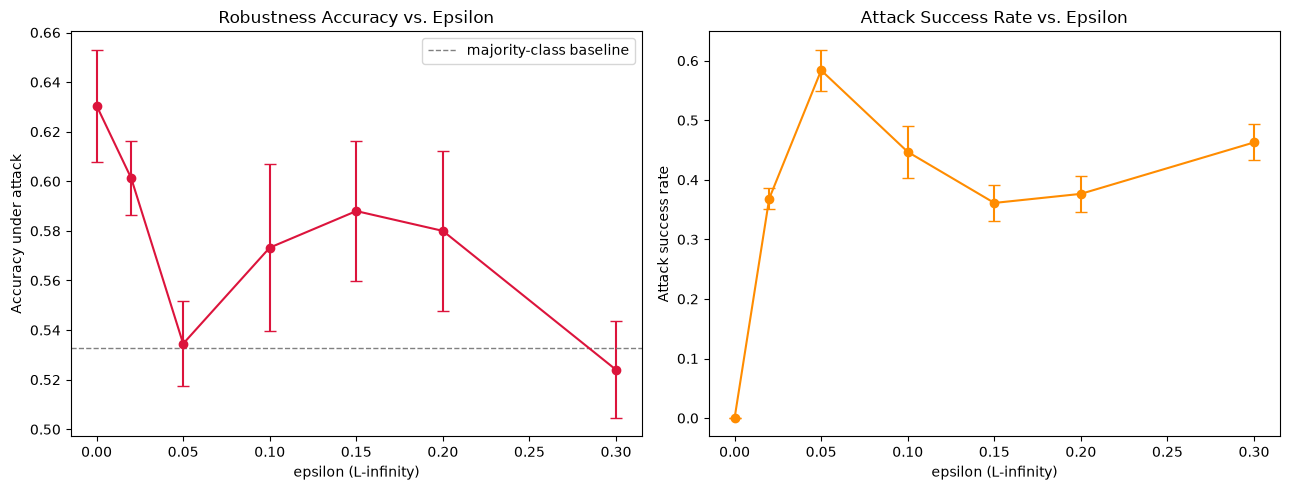

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

grouped = df.groupby("epsilon")[["accuracy", "attack_success_rate"]].agg(["mean", "std"])

ax1.errorbar(grouped.index, grouped[("accuracy", "mean")], yerr=grouped[("accuracy", "std")],
             marker="o", capsize=4, color="crimson")
ax1.axhline(0.5328, color="gray", linestyle="--", linewidth=1, label="majority-class baseline")
ax1.set_xlabel("epsilon (L-infinity)")
ax1.set_ylabel("Accuracy under attack")
ax1.set_title("Robustness Accuracy vs. Epsilon")
ax1.legend()

ax2.errorbar(grouped.index, grouped[("attack_success_rate", "mean")], yerr=grouped[("attack_success_rate", "std")],
             marker="o", capsize=4, color="darkorange")
ax2.set_xlabel("epsilon (L-infinity)")
ax2.set_ylabel("Attack success rate")
ax2.set_title("Attack Success Rate vs. Epsilon")

plt.tight_layout()
fig.savefig(PROJECT_ROOT / "results" / "fgsm_sweep" / "fgsm_accuracy_and_success_vs_epsilon.png", dpi=150)
plt.show()

## PGD (optional extension)

The thesis proposal names PGD (Projected Gradient Descent) as an
optional addition ("PGD attacks may be included if time permits").
Added here to check whether the non-monotonic FGSM attack-success
curve above is a property of the decision boundary itself, or an
artifact of FGSM's single linearized gradient step -- PGD takes
multiple smaller steps, re-projecting onto the epsilon-ball each time,
and is the standard stronger benchmark attack in adversarial ML.

**Scope**: PGD costs ~180ms/sample-epsilon-iteration for the VQC (same
per-step cost as FGSM, multiplied by iterations) -- full FGSM-scale
would cost ~14 hours across 8 seeds. Since this is explicitly optional,
`evaluate_pgd_sweep.py` runs on a smaller 50-sample subsample, 5
epsilons, 7 iterations (`eps_step = 0.25 * epsilon`) -- for both the
VQC and the classical baseline, so the comparison from `10_statistical_analysis`
extends to PGD too.

In [4]:
pgd_df = pd.read_csv(PROJECT_ROOT / "results" / "pgd_sweep" / "pgd_sweep_all_seeds.csv")
vqc_pgd = pgd_df[pgd_df.model == "vqc"]
classical_pgd = pgd_df[pgd_df.model == "classical"]

print(pgd_df.groupby(["model", "epsilon"])[["accuracy", "attack_success_rate"]].agg(["mean", "std"]).round(4))

                  accuracy         attack_success_rate        
                      mean     std                mean     std
model     epsilon                                             
classical 0.00      0.9800  0.0000              0.0000  0.0000
          0.05      0.9800  0.0000              0.0000  0.0000
          0.10      0.9850  0.0093              0.0000  0.0000
          0.20      1.0000  0.0000              0.0000  0.0000
          0.30      0.9925  0.0149              0.0077  0.0152
vqc       0.00      0.6425  0.0922              0.0000  0.0000
          0.05      0.4475  0.0900              0.8151  0.0797
          0.10      0.3700  0.0814              0.9569  0.0376
          0.20      0.4450  0.0826              0.8246  0.0543
          0.30      0.4875  0.0684              0.6364  0.0503


**Result: PGD is dramatically stronger than FGSM against the VQC.**
Attack success rate reaches 81.5% at epsilon=0.05 and peaks at **95.7%
at epsilon=0.1** -- compared to FGSM's peak of only 58.4% at the same
epsilon=0.05. A paired comparison at the four epsilons common to both
attacks confirms this is significant, not noise (Wilcoxon FDR-corrected
p=0.0078 -- the minimum achievable at n=8 -- at all four, Cohen's d
from 2.6 to 10.3).

**The classical baseline remains essentially immune even to this much
stronger attack**: 0% attack success through epsilon=0.2, only 0.8% at
epsilon=0.3 -- reinforcing rather than overturning the RQ(e) finding
that the classical model is dramatically more adversarially robust,
not just lucky against a weak single-step attack.

**Interpretation**: the non-monotonic FGSM curve (peak-then-dip-then-
rise) does appear to be at least partly an artifact of FGSM's single
linearized step -- PGD's iterative refinement finds a much more
direct, consistently high-success path to misclassification,
especially at small-to-moderate epsilon. This is worth noting as a
methodological point: **FGSM alone would have understated the VQC's
adversarial vulnerability** at epsilon=0.1 by nearly 40 percentage
points (58.4% vs. PGD's 95.7% at the nearby epsilon=0.05, and FGSM
never tested above ~58% anywhere in its sweep). Any thesis conclusion
about "how vulnerable is this VQC" should lead with the PGD numbers,
not FGSM's.

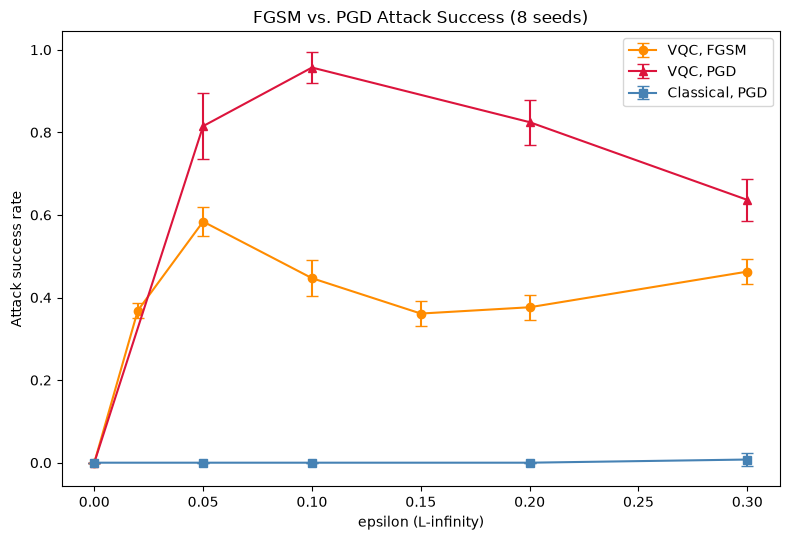

In [5]:
fig, ax = plt.subplots(figsize=(8, 5.5))

fgsm_df = pd.read_csv(PROJECT_ROOT / "results" / "fgsm_sweep" / "fgsm_sweep_all_seeds.csv")
fgsm_grouped = fgsm_df.groupby("epsilon")["attack_success_rate"].agg(["mean", "std"])
vqc_pgd_grouped = vqc_pgd.groupby("epsilon")["attack_success_rate"].agg(["mean", "std"])
classical_pgd_grouped = classical_pgd.groupby("epsilon")["attack_success_rate"].agg(["mean", "std"])

ax.errorbar(fgsm_grouped.index, fgsm_grouped["mean"], yerr=fgsm_grouped["std"],
            marker="o", capsize=4, color="darkorange", label="VQC, FGSM")
ax.errorbar(vqc_pgd_grouped.index, vqc_pgd_grouped["mean"], yerr=vqc_pgd_grouped["std"],
            marker="^", capsize=4, color="crimson", label="VQC, PGD")
ax.errorbar(classical_pgd_grouped.index, classical_pgd_grouped["mean"], yerr=classical_pgd_grouped["std"],
            marker="s", capsize=4, color="steelblue", label="Classical, PGD")

ax.set_xlabel("epsilon (L-infinity)")
ax.set_ylabel("Attack success rate")
ax.set_title("FGSM vs. PGD Attack Success (8 seeds)")
ax.legend()

plt.tight_layout()
fig.savefig(PROJECT_ROOT / "results" / "pgd_sweep" / "fgsm_vs_pgd_comparison.png", dpi=150)
plt.show()

## Next

`08_noise_attack_sweep.ipynb` composes noise and adversarial attacks
together: FGSM examples generated against the clean (noiseless) model
(as here) are evaluated under each noise condition from
`06_noise_models.ipynb`, answering sub-RQ(a)/(b) for adversarial
robustness specifically -- generating adversarial examples against a
noise-affected model directly isn't attempted (ART's FGSM needs a
differentiable, deterministic forward pass; a shot-based Aer forward
pass is stochastic and not straightforwardly differentiable through
the parameter-shift chain), so this measures attack *transfer* under
noise, not an adaptive noise-aware attacker -- a documented scope
limitation, not an oversight.